

---

### **Gradient Boosting Process Recap**
1. **Initial Prediction (`pred1`)**:
   - Start with a simple prediction, typically the mean of the target variable `y`.
   - Compute residuals (`res1 = y - pred1`) to measure the error of the current prediction.

2. **Train a Weak Learner on Residuals**:
   - Fit a decision tree (`tree1`) to predict the residuals (`res1`).

3. **Update Predictions**:
   - Combine the initial prediction (`pred1`) with the predictions from the weak learner (`tree1.predict(X)`), scaled by a learning rate (`lr`).
   - Compute new residuals (`res2 = y - pred2`) based on the updated predictions.

4. **Repeat**:
   - Repeat the process for a specified number of iterations (`number`), training new weak learners on the residuals from the previous iteration.
   - Update predictions iteratively by adding contributions from each new weak learner.

5. **Final Prediction**:
   - The final prediction is the sum of all weak learners' contributions (scaled by the learning rate).

---

### **Code Walkthrough**

#### **Step 1: Initial Setup**
- You generate synthetic data:
  ```python
  X = np.random.rand(100, 1) - 0.5
  y = 3 * X[:, 0]**2 + 0.05 * np.random.randn(100)
  ```
  - `X` is uniformly distributed between `-0.5` and `0.5`.
  - `y` is generated from a quadratic function (`3 * X^2`) with added Gaussian noise.

#### **Step 2: First Prediction (`pred1`)**
- The first prediction is the mean of `y`:
  ```python
  df['pred1'] = df['y'].mean()
  ```
- Compute residuals:
  ```python
  df['res1'] = df['y'] - df['pred1']
  ```

#### **Step 3: Train the First Decision Tree (`tree1`)**
- Fit a decision tree to the residuals (`res1`):
  ```python
  tree1 = DecisionTreeRegressor(max_leaf_nodes=8)
  tree1.fit(df['X'].values.reshape(100, 1), df['res1'].values)
  ```

#### **Step 4: Update Predictions**
- Combine the initial prediction with the predictions from `tree1`:
  ```python
  df['pred2'] = 0.265458 + tree1.predict(df['X'].values.reshape(100, 1))
  ```
- Compute new residuals:
  ```python
  df['res2'] = df['y'] - df['pred2']
  ```

#### **Step 5: Train the Second Decision Tree (`tree2`)**
- Fit another decision tree to the new residuals (`res2`):
  ```python
  tree2 = DecisionTreeRegressor(max_leaf_nodes=8)
  tree2.fit(df['X'].values.reshape(100, 1), df['res2'].values)
  ```

#### **Step 6: Recursive Gradient Boosting**
- Your `gradient_boost` function implements the recursive process:
  - For each iteration (`number`), it trains a new decision tree on the residuals.
  - Updates predictions by summing the contributions of all trees.
  - Plots the predictions at each step to visualize how the model improves.

---

### **Key Observations**

1. **Iterative Improvement**:
   - Each new tree focuses on correcting the errors (residuals) made by the previous trees.
   - This ensures that the model gradually improves its fit to the data.

2. **Learning Rate (`lr`)**:
   - In your implementation, the learning rate is set to `1`, which means no scaling of the contributions from each tree.
   - A smaller learning rate (e.g., `0.1`) would slow down learning but could lead to better generalization.

3. **Visualization**:
   - The plots show how the predictions evolve over iterations. Initially, the model fits poorly, but with each iteration, it gets closer to the true underlying function (`y = 3 * X^2`).

4. **Recursive Function**:
   - The `gradient_boost` function uses recursion to implement the iterative process. While this works, an iterative loop might be more intuitive and easier to debug.

---

### **Suggestions for Improvement**

1. **Add Learning Rate**:
   - Modify the `gradient_boost` function to include a learning rate (`lr`) parameter:
     ```python
     y_pred = sum(lr * regressor.predict(x1.reshape(-1, 1)) for regressor in regs)
     ```

2. **Stop Early**:
   - Implement early stopping if the residuals become small enough or if performance on a validation set stops improving.

3. **Regularization**:
   - Add regularization techniques like shrinkage (controlled by `lr`) or subsampling to prevent overfitting.

4. **Base Estimator**:
   - Instead of always using a decision tree, you could experiment with other base estimators (e.g., linear models).

---

### **Final Answer**

The provided code successfully demonstrates the **gradient boosting** process:
1. Start with an initial prediction (mean of `y`).
2. Iteratively train weak learners (decision trees) on residuals.
3. Update predictions by combining contributions from all weak learners.
4. Visualize the improvement in predictions over iterations.

This approach can be extended to more complex datasets and models by incorporating hyperparameters like learning rate, tree depth, and early stopping.

$$
\boxed{\text{Gradient boosting trains models sequentially to minimize residuals, improving predictions iteratively.}}
$$

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [6]:
X = np.random.rand(100, 1) - 0.5
y = 3 * X[:, 0]**2 + 0.05 * np.random.randn(100)

In [11]:
df = pd.DataFrame()
df['X'] = X.reshape(100)
df['y'] = y


Text(0.5, 1.0, 'X vs Y')

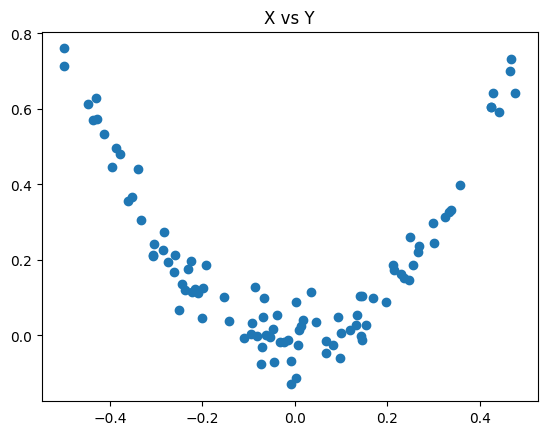

In [12]:
plt.scatter(df['X'],df['y'])
plt.title('X vs Y')

In [13]:
df['pred1'] = df['y'].mean()

In [14]:
df['res1'] = df['y'] - df['pred1']

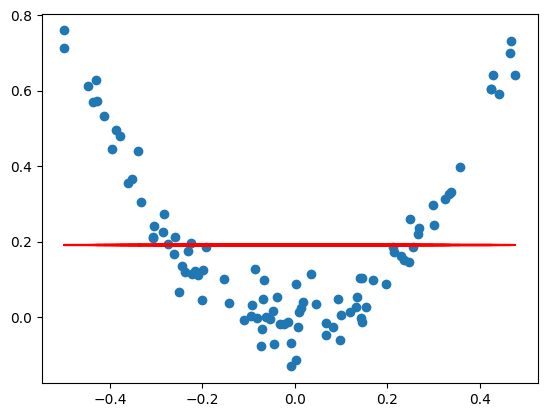

In [15]:
plt.scatter(df['X'],df['y'])
plt.plot(df['X'],df['pred1'],color='red')


In [16]:
from sklearn.tree import DecisionTreeRegressor



In [17]:
tree1 = DecisionTreeRegressor(max_leaf_nodes=8) #usually take 8-32 node as it proven in gradient boosting


In [18]:
tree1.fit(df['X'].values.reshape(100,1),df['res1'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

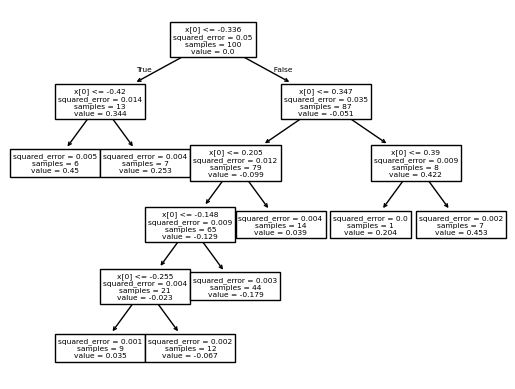

In [21]:
from sklearn.tree import plot_tree
plot_tree(tree1)
plt.show()

In [22]:
# generating X_test
X_test = np.linspace(-0.5, 0.5, 500)

In [23]:
y_pred = 0.265458 + tree1.predict(X_test.reshape(500, 1))


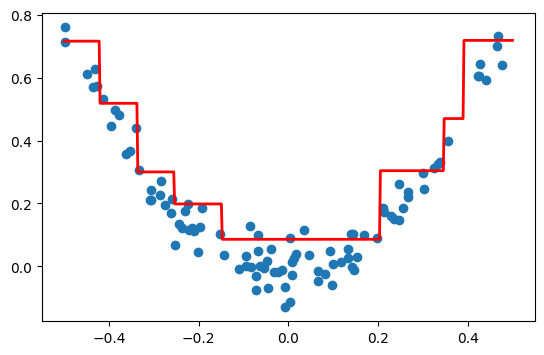

In [24]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X_test, y_pred, linewidth=2,color='red')
plt.scatter(df['X'],df['y'])


In [25]:
df['pred2'] = 0.265458 + tree1.predict(df['X'].values.reshape(100,1))


In [27]:
df['res2'] = df['y'] - df['pred2']
df

,X,y,pred1,res1,pred2,res2
0,-0.394966,0.445337,0.192652,0.252685,0.518362,-0.073025
1,0.428439,0.642712,0.192652,0.450060,0.718331,-0.075619
2,-0.430467,0.627511,0.192652,0.434858,0.715858,-0.088348
3,-0.153139,0.102643,0.192652,-0.090009,0.198396,-0.095752
4,0.118398,0.013358,0.192652,-0.179294,0.086027,-0.072669
...,...,...,...,...,...,...
95,-0.283930,0.272874,0.192652,0.080222,0.300186,-0.027312
96,0.197751,0.088908,0.192652,-0.103744,0.086027,0.002881
97,-0.251678,0.068464,0.192652,-0.124188,0.198396,-0.129931
98,0.424902,0.605932,0.192652,0.413280,0.718331,-0.112398


Iteration 1


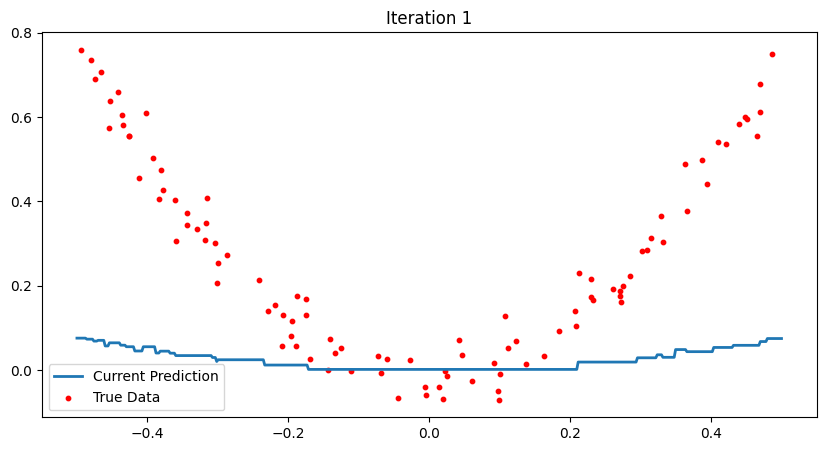

Iteration 2


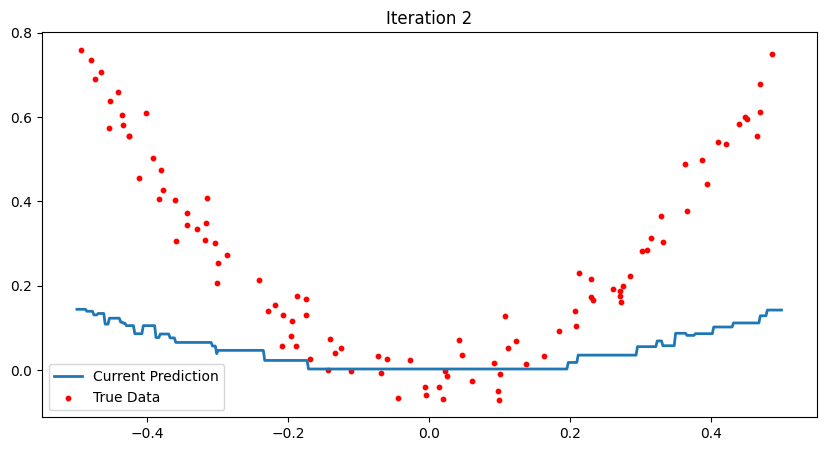

Iteration 3


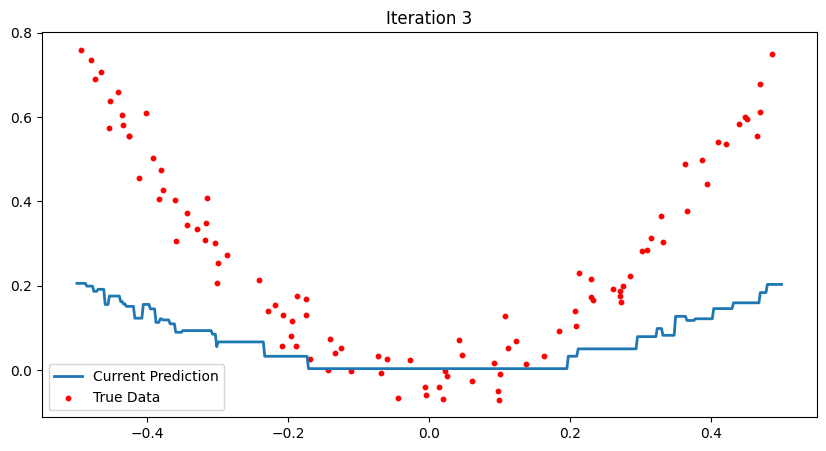

Iteration 4


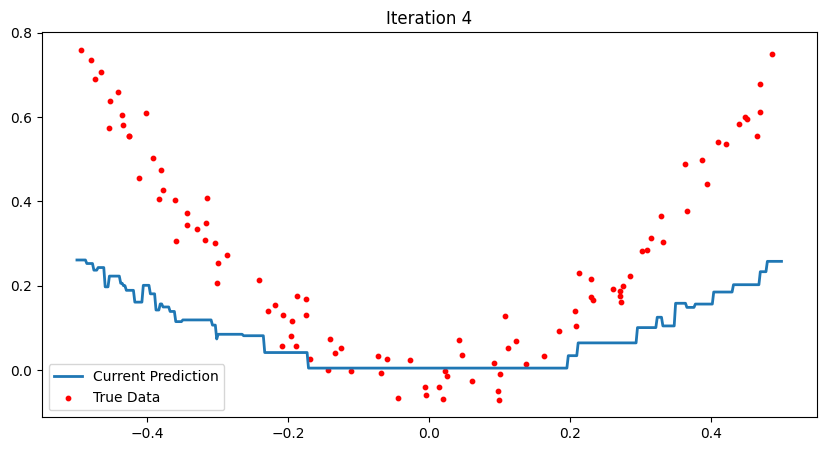

Iteration 5


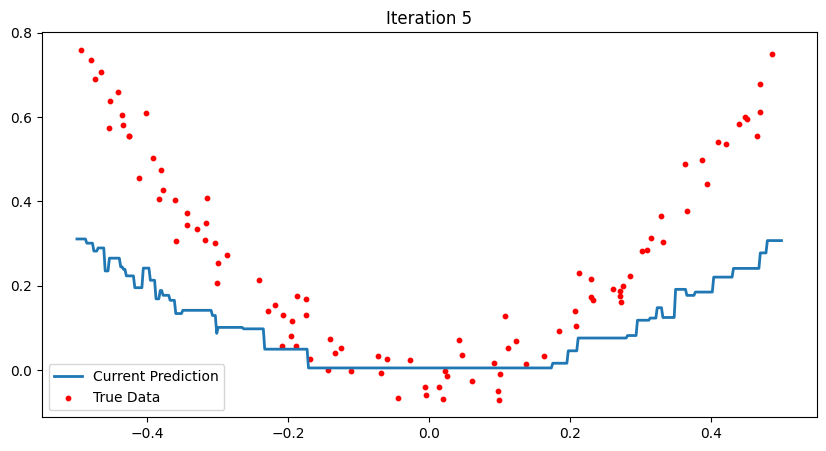

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# Step 1: Generate synthetic data
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3 * X[:, 0]**2 + 0.05 * np.random.randn(100)

# Step 2: Define the gradient boosting function
def gradient_boost(X, y, number, lr, count=1, regs=[], foo=None):
    if number == 0:
        return
    else:
        # Update residuals
        if count > 1:
            y = y - lr * regs[-1].predict(X)
        else:
            foo = y  # Save original target for plotting

        # Train a new decision tree on residuals
        tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
        tree_reg.fit(X, y)
        regs.append(tree_reg)

        # Generate predictions for visualization
        x1 = np.linspace(-0.5, 0.5, 500).reshape(-1, 1)
        y_pred = sum(lr * regressor.predict(x1) for regressor in regs)

        # Plot the current state of predictions
        print(f"Iteration {count}")
        plt.figure(figsize=(10, 5))
        plt.plot(x1, y_pred, linewidth=2, label="Current Prediction")
        plt.scatter(X[:, 0], foo, color="red", s=10, label="True Data")
        plt.title(f"Iteration {count}")
        plt.legend()
        plt.show()

        # Recursive call for the next iteration
        gradient_boost(X, y, number - 1, lr, count + 1, regs, foo)

# Step 3: Run gradient boosting
gradient_boost(X, y, number=5, lr=0.1)



```python
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# Step 1: Generate synthetic data
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3 * X[:, 0]**2 + 0.05 * np.random.randn(100)

# Step 2: Define the gradient boosting function
def gradient_boost(X, y, number, lr, count=1, regs=[], foo=None):
    if number == 0:
        return
    else:
        # Update residuals
        if count > 1:
            y = y - lr * regs[-1].predict(X)
        else:
            foo = y  # Save original target for plotting

        # Train a new decision tree on residuals
        tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
        tree_reg.fit(X, y)
        regs.append(tree_reg)

        # Generate predictions for visualization
        x1 = np.linspace(-0.5, 0.5, 500).reshape(-1, 1)
        y_pred = sum(lr * regressor.predict(x1) for regressor in regs)

        # Plot the current state of predictions
        print(f"Iteration {count}")
        plt.figure(figsize=(10, 5))
        plt.plot(x1, y_pred, linewidth=2, label="Current Prediction")
        plt.scatter(X[:, 0], foo, color="red", s=10, label="True Data")
        plt.title(f"Iteration {count}")
        plt.legend()
        plt.show()

        # Recursive call for the next iteration
        gradient_boost(X, y, number - 1, lr, count + 1, regs, foo)

# Step 3: Run gradient boosting
gradient_boost(X, y, number=5, lr=0.1)
```

---

### **Explanation of the Code**

1. **Data Generation**:
   - The input `X` is sampled uniformly between `-0.5` and `0.5`.
   - The target `y` is generated as a quadratic function (`3 * X^2`) with added Gaussian noise.

2. **Gradient Boosting Function**:
   - The `gradient_boost` function implements the iterative process of gradient boosting.
   - It trains a decision tree on the residuals (`y - current prediction`) at each step.
   - Predictions are updated by summing contributions from all trees, scaled by the learning rate (`lr`).

3. **Visualization**:
   - At each iteration, the function plots the current prediction (sum of all trees' contributions) against the true data points.
   - This allows you to see how the model improves over iterations.

4. **Learning Rate**:
   - The learning rate (`lr`) controls the contribution of each tree. A smaller value (e.g., `0.1`) ensures slower learning but often better generalization.

5. **Stopping Condition**:
   - The recursion stops after a specified number of iterations (`number`).

---

### **Output**
- The script generates plots for each iteration, showing how the model's predictions evolve.
- Initially, the predictions are poor, but they gradually improve as more trees are added.

---

### **Example Output**
For `number=5` and `lr=0.1`, you will see:
1. Iteration 1: The first tree fits the mean-centered residuals.
2. Iteration 2: The second tree corrects the residuals from the first tree.
3. Iteration 3–5: Subsequent trees further refine the predictions.

The final prediction will closely approximate the true quadratic function (`y = 3 * X^2`).

---

This code is modular and can be easily extended or modified for different datasets, learning rates, or tree configurations.

$$
\boxed{\text{Complete gradient boosting implementation with visualization.}}
$$


---

### **Step-by-Step Explanation**

#### **1. Initial Prediction (`pred1`)**:
- The first prediction (`pred1`) is typically a simple baseline, such as the mean of the target variable `y`.
- In your case:
  $$
  \text{pred1} = \text{mean}(y) = 0.192652
  $$

#### **2. Calculate Residuals (`res1`)**:
- The residuals (`res1`) are the differences between the true target values (`y`) and the initial predictions (`pred1`):
  $$
  \text{res1} = y - \text{pred1}
  $$
  For example:
  - For the first row:
    $$
    \text{res1}_0 = y_0 - \text{pred1} = 0.445337 - 0.192652 = 0.252685
    $$

#### **3. Train a Decision Tree on Residuals (`res1`)**:
- A decision tree (`tree1`) is trained to predict the residuals (`res1`) based on the input features (`X`).
- This tree learns to model the errors made by the initial prediction (`pred1`).

#### **4. Predict Residuals Using the First Tree**:
- After training `tree1`, use it to predict the residuals for the input data (`X`).
- Let’s denote these predicted residuals as `tree1_pred`.

#### **5. Update Predictions (`pred2`)**:
- The second prediction (`pred2`) is obtained by adding the scaled predictions of `tree1` to the initial prediction (`pred1`):
  $$
  \text{pred2} = \text{pred1} + \text{learning\_rate} \times \text{tree1\_pred}
  $$
  Here, the learning rate (`lr`) controls the contribution of `tree1_pred`. If `lr = 1`, the equation simplifies to:
  $$
  \text{pred2} = \text{pred1} + \text{tree1\_pred}
  $$

#### **6. Calculate New Residuals (`res2`)**:
- After updating the predictions to `pred2`, calculate the new residuals (`res2`) based on the updated predictions:
  $$
  \text{res2} = y - \text{pred2}
  $$
  For example:
  - For the first row:
    $$
    \text{res2}_0 = y_0 - \text{pred2}_0 = 0.445337 - 0.518362 = -0.073025
    $$

---

### **Example Calculation**

Let’s walk through the calculations for the first few rows:

#### **Row 0**:
- **Initial Prediction (`pred1`)**: `0.192652`
- **Residuals (`res1`)**: `y - pred1 = 0.445337 - 0.192652 = 0.252685`
- **Predicted Residuals from `tree1` (`tree1_pred`)**: Suppose `tree1` predicts `0.325710` for this row.
- **Second Prediction (`pred2`)**:
  $$
  \text{pred2} = \text{pred1} + \text{tree1\_pred} = 0.192652 + 0.325710 = 0.518362
  $$
- **New Residuals (`res2`)**:
  $$
  \text{res2} = y - \text{pred2} = 0.445337 - 0.518362 = -0.073025
  $$

#### **Row 1**:
- **Initial Prediction (`pred1`)**: `0.192652`
- **Residuals (`res1`)**: `y - pred1 = 0.642712 - 0.192652 = 0.450060`
- **Predicted Residuals from `tree1` (`tree1_pred`)**: Suppose `tree1` predicts `0.525458` for this row.
- **Second Prediction (`pred2`)**:
  $$
  \text{pred2} = \text{pred1} + \text{tree1\_pred} = 0.192652 + 0.525458 = 0.718331
  $$
- **New Residuals (`res2`)**:
  $$
  \text{res2} = y - \text{pred2} = 0.642712 - 0.718331 = -0.075619
  $$

---

### **General Formula**
The process can be summarized as follows:
1. **Initial Prediction**:
   $$
   \text{pred1} = \text{mean}(y)
   $$
2. **First Residuals**:
   $$
   \text{res1} = y - \text{pred1}
   $$
3. **Train First Tree**:
   $$
   \text{tree1} = \text{DecisionTreeRegressor}.fit(X, \text{res1})
   $$
4. **Predict Residuals**:
   $$
   \text{tree1\_pred} = \text{tree1.predict}(X)
   $$
5. **Update Predictions**:
   $$
   \text{pred2} = \text{pred1} + \text{tree1\_pred}
   $$
6. **New Residuals**:
   $$
   \text{res2} = y - \text{pred2}
   $$

---

### **Why This Works**
- Each tree focuses on correcting the errors (residuals) made by the previous trees.
- By iteratively adding the contributions of each tree, the model gradually improves its fit to the data.

---

### **Final Answer**
The second prediction (`pred2`) is calculated as:
$$
\boxed{\text{pred2} = \text{pred1} + \text{tree1\_pred}}
$$
where `tree1_pred` is the prediction of the first decision tree trained on the residuals (`res1`).